<a href="https://colab.research.google.com/github/adi45-del/Decision-Trees-and-Random-Forests-Task-5-/blob/main/AL_ML(Task_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

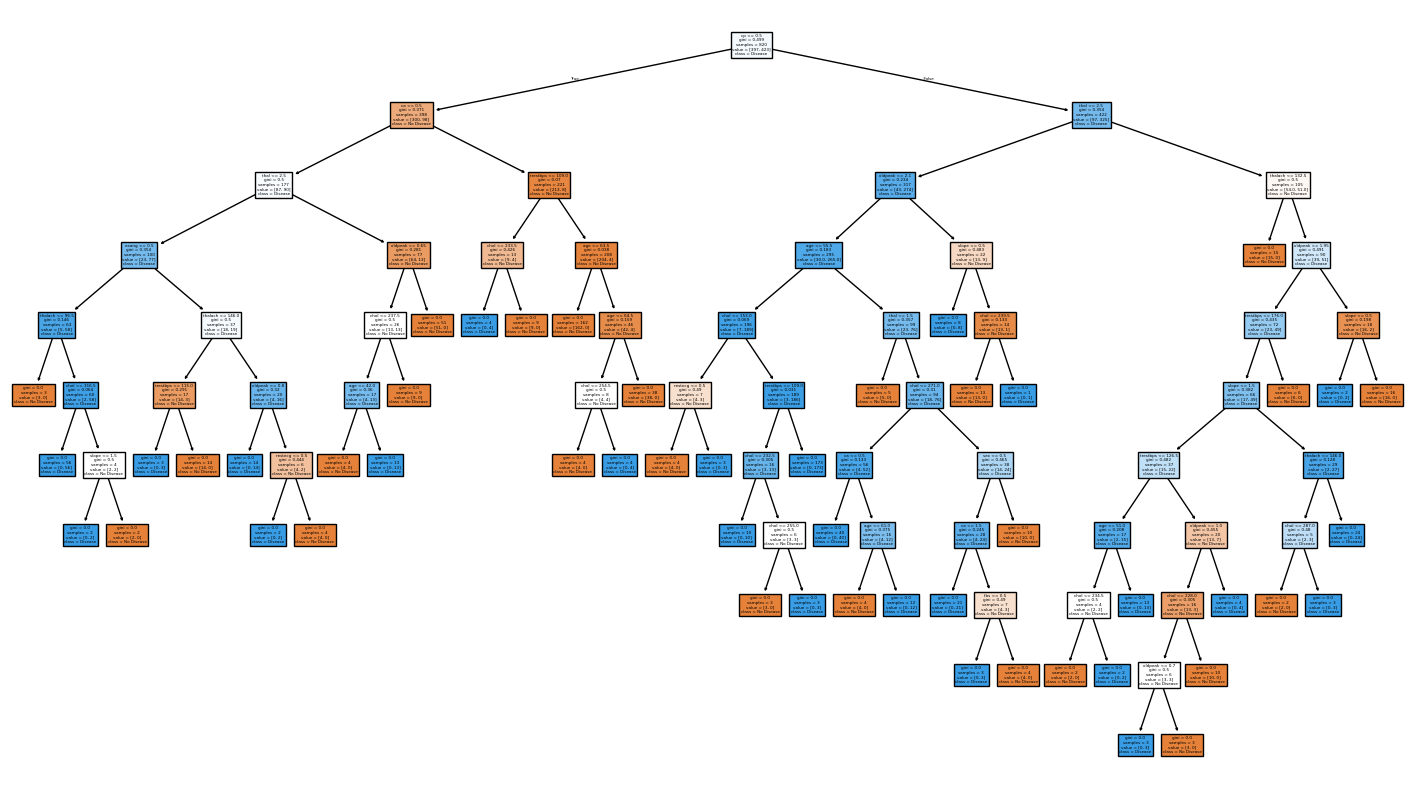

Decision Tree Accuracy: 0.9853658536585366
Random Forest Accuracy: 0.9853658536585366
     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444
[1.         1.         1.         1.         0.98536585]
Average Accuracy: 0.9970731707317073


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df=pd.read_csv("heart.csv")
print(df.head())
print(df.info())
print(df.shape)

print(df.isnull().sum())
X=df.drop("target",axis=1)
y=df["target"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
tree=DecisionTreeClassifier(random_state=42)
tree.fit(X_train,y_train)
y_pred=tree.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print("Decision tree Accuracy:",accuracy)

plt.figure(figsize=(18,10))
plot_tree(tree,feature_names=X.columns,class_names=["No Disease","Disease"],filled=True)
plt.show()

tree =DecisionTreeClassifier(max_depth=4,random_state=42)
tree.fit(X_train,y_train)

rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf.pred=rf.predict(X_test)

rf_accuracy=accuracy_score(y_test, rf.pred)
print("Decision Tree Accuracy:",accuracy)
print("Random Forest Accuracy:",rf_accuracy)
importance=pd.DataFrame({
    "Feature":X.columns,"Importance":rf.feature_importances_})
print(importance.sort_values(by="Importance",ascending=False))

scores=cross_val_score(
    rf,X,y,cv=5)

print(scores)
print("Average Accuracy:",scores.mean())



In [4]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart (1).csv
